# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, compare the cleaned EPA PM2.5 monitor dataset with the extracted alternative PM2.5 estimates on a daily basis to assess the quality of the alternative dataset.

#### **Scope:** EPA monitor locations and their daily PM2.5 measurements in the contiguous United States in 2019 and daily PM2.5 estimates derived from an alternative air quality dataset during the same time period and frequency.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | _daily\_88101\_2019.csv_ | Derived from the U.S. EPA Pre\-Generated Data Files webpage on 10/28/2025, this dataset contains the PM2.5 air monitor data for every day in the year 2019 for all monitors in the United States and its territories;                                                                                                    \-\- Data Dictionary: [https://www.epa.gov/aqs/aqs\-data\-dictionary](https://www.epa.gov/aqs/aqs-data-dictionary) | [https://aqs.epa.gov/aqsweb/airdata/download\_files.html\#Daily](https://aqs.epa.gov/aqsweb/airdata/download_files.html#Daily) \(see "Particulates" and "2019"\) |
| 2. | USHAP\_PM2.5\_D1K\_2019\_V1.zip | Derived from research out of the Universities of Maryland and Iowa on 11/03/2025, this dataset contains 1\-kilometer resolution PM2.5 estimates in the contiguous United States for every day in the year 2019. The dataset was generated from big data \(e.g., ground\-based measurements, satellite remote sensing products, atmospheric reanalysis, and model simulations\) using artificial intelligence. The researchers show their estimates align well with physical measurements, with 0.82 cross\-validated coefficients of determination. | Paper: [https://www.thelancet.com/journals/lanplh/article/PIIS2542\-5196\(23\)00235\-8/fulltext](https://www.thelancet.com/journals/lanplh/article/PIIS2542-5196(23)00235-8/fulltext) <br> <br>  Data: <br> https://zenodo.org/records/7884640 |

#### **Conclusions:** TBD.



#### General Methodology

##### Steps

1. TBD

##### Pseudocode

1. TBD

#### Load Libraries



In [4]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))

if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(stringr)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)

#### Monitors with Alternative PM2.5 Data \- Exploration of Dataset



In [5]:
#Purpose of Cell Block: Load Processed AQM+AltPM25 Dataset 
setwd("/home/user/capstone/A_data")
DF_altpm25_processed <- read.csv("D_processed_data/alternative_PM25_data/alternative_PM25_data_processed_v02.csv") %>%
    mutate('AQS_Site_ID' = str_pad(AQS_Site_ID, width = 9, pad = 0)) %>% #pad leading zero so state code always 9 char
    mutate(Date = as.Date(Date)) #converting date value from character to date

head(DF_altpm25_processed)

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,PM25_ugm3,Date,Alt_PM25
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<date>,<dbl>
1,011130003,32.43703,-84.99965,"510 6th Place South, Phenix City, Alabama 36869",Alabama,Russell,Phenix City,4.791667,2019-01-01,4.8
2,011130003,32.43703,-84.99965,"510 6th Place South, Phenix City, Alabama 36869",Alabama,Russell,Phenix City,4.700000,2019-01-01,4.8
3,040031005,31.34920,-109.53968,1445-1449 15TH STREET,Arizona,Cochise,Douglas,3.833333,2019-01-01,3.8
4,040031005,31.34920,-109.53968,1445-1449 15TH STREET,Arizona,Cochise,Douglas,3.800000,2019-01-01,3.8
5,040128000,34.24390,-113.55860,ALAMO LAKE STATE PARK,Arizona,La Paz,Wenden,4.000000,2019-01-01,4.0
6,040130019,33.48378,-112.14256,3847 W EARLL DR-WEST PHOENIX STATION,Arizona,Maricopa,Phoenix,18.254167,2019-01-01,18.3


In [6]:
#Purpose of Cell: Check Missingness

glimpse(DF_altpm25_processed)
summary(DF_altpm25_processed)

#Visualize missingness
print("Variables with Missing Data (Percent):")
DF_altpm25_processed %>%
    summarise(across(everything(), ~mean(is.na(.)) * 100)) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "missing_percent")  %>%
    filter(missing_percent > 0)

#Conclusion: Missingness doesn't appear to be a significant problem in the dataset, though I need to check the type of missingness.

Rows: 616,432
Columns: 10
$ AQS_Site_ID <chr> "011130003", "011130003", "040031005", "040031005", "04012…
$ Latitude    <dbl> 32.43703, 32.43703, 31.34920, 31.34920, 34.24390, 33.48378…
$ Longitude   <dbl> -84.99965, -84.99965, -109.53968, -109.53968, -113.55860, …
$ Address     <chr> "510 6th Place South, Phenix City, Alabama  36869", "510 6…
$ State       <chr> "Alabama", "Alabama", "Arizona", "Arizona", "Arizona", "Ar…
$ County      <chr> "Russell", "Russell", "Cochise", "Cochise", "La Paz", "Mar…
$ City        <chr> "Phenix City", "Phenix City", "Douglas", "Douglas", "Wende…
$ PM25_ugm3   <dbl> 4.791667, 4.700000, 3.833333, 3.800000, 4.000000, 18.25416…
$ Date        <date> 2019-01-01, 2019-01-01, 2019-01-01, 2019-01-01, 2019-01-0…
$ Alt_PM25    <dbl> 4.8, 4.8, 3.8, 3.8, 4.0, 18.3, 18.3, 14.0, 14.0, 16.9, 16.…


 AQS_Site_ID           Latitude       Longitude         Address         
 Length:616432      Min.   :25.47   Min.   :-124.18   Length:616432     
 Class :character   1st Qu.:35.62   1st Qu.:-106.60   Class :character  
 Mode  :character   Median :39.49   Median : -89.44   Mode  :character  
                    Mean   :38.76   Mean   : -93.54                     
                    3rd Qu.:41.77   3rd Qu.: -80.73                     
                    Max.   :48.76   Max.   : -68.02                     
                                                                        
    State              County              City             PM25_ugm3      
 Length:616432      Length:616432      Length:616432      Min.   : -5.200  
 Class :character   Class :character   Class :character   1st Qu.:  4.242  
 Mode  :character   Mode  :character   Mode  :character   Median :  6.348  
                                                          Mean   :  7.347  
                                    

[1] "Variables with Missing Data (Percent):"


variable,missing_percent
<chr>,<dbl>
Alt_PM25,0.3833351


Warning message:
“Removed 2363 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


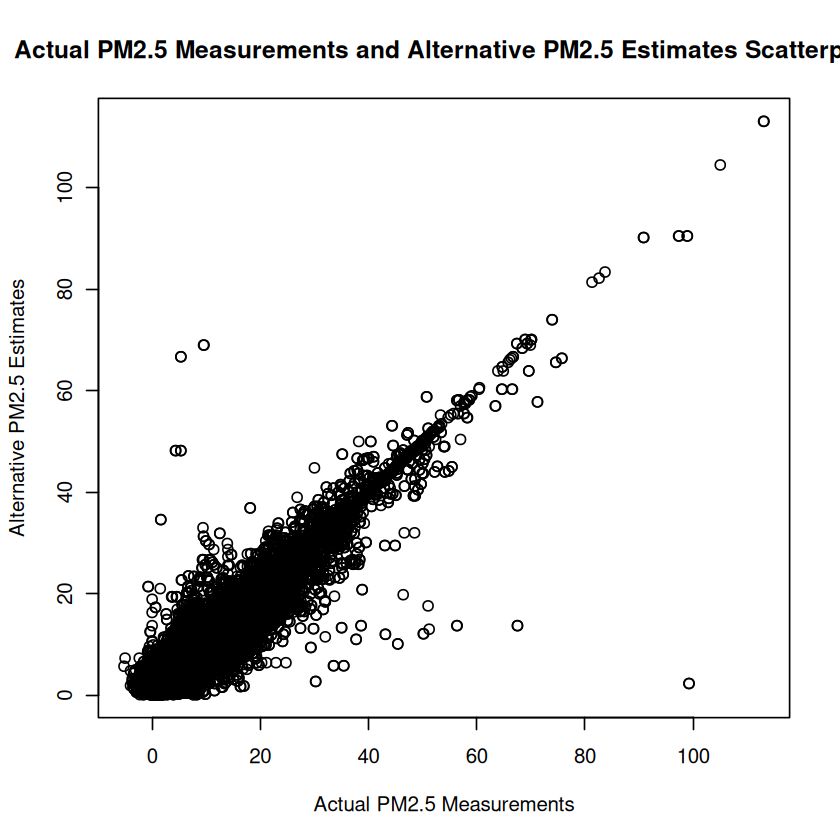

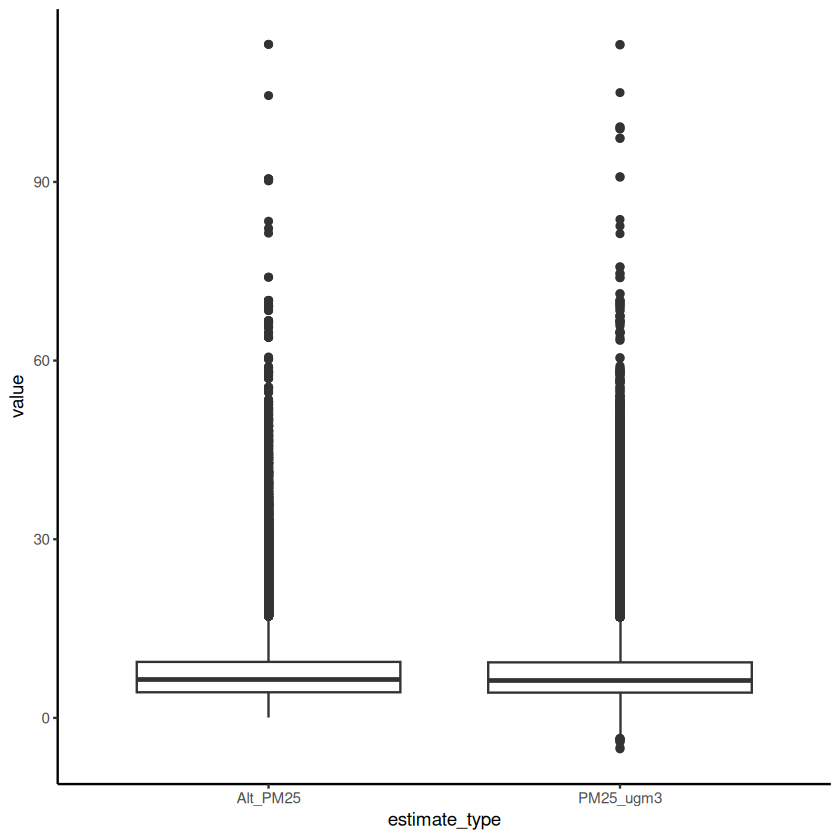

In [17]:
#Purpose of Cell: Assess variabels for possible correlation and identify any outliers
plot(
    x = DF_altpm25_processed$PM25_ugm3, 
    y = DF_altpm25_processed$Alt_PM25, 
    xlab = "Actual PM2.5 Measurements", 
    ylab = "Alternative PM2.5 Estimates", 
    main = "Actual PM2.5 Measurements and Alternative PM2.5 Estimates Scatterplot"
)

#Look for outliers
DF_altpm25_processed %>%
    pivot_longer(c(PM25_ugm3, Alt_PM25), names_to="estimate_type", values_to="value") %>%
    ggplot(aes(x=estimate_type, y=value)) +
    geom_boxplot() +
    theme_classic()

#Conclusion: The variables appear to correlate well with each other, though there are several outliers that may need to be addressed.

Warning message:
“Removed 2363 rows containing non-finite outside the scale range (`stat_bin()`).”


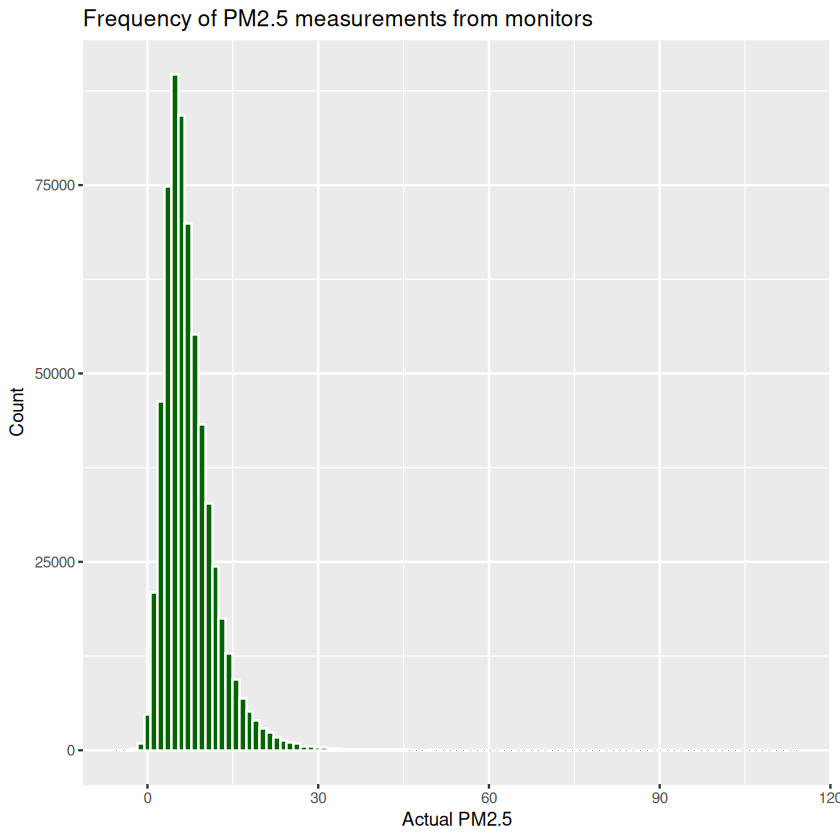

Warning message:
“Removed 2363 rows containing non-finite outside the scale range
(`stat_density()`).”


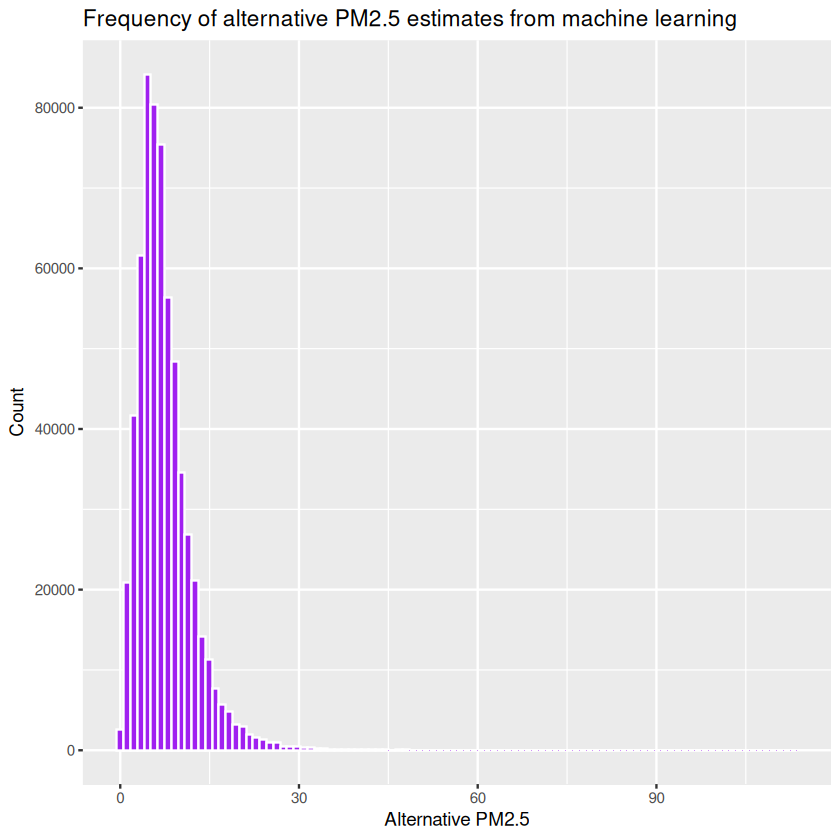

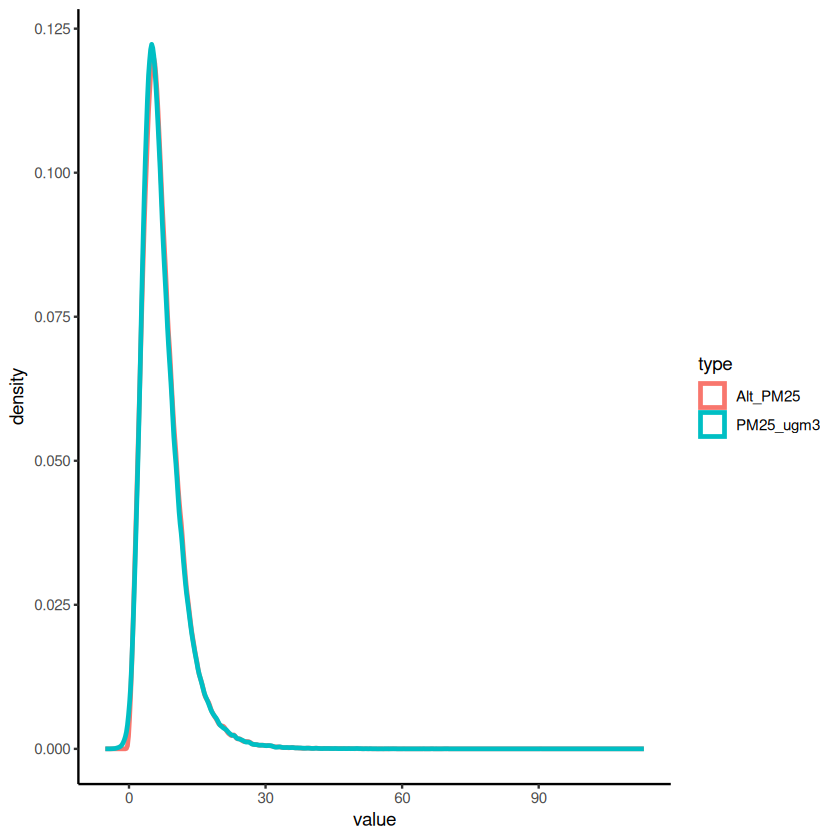

In [8]:
#Purpose of Cell: Check the shape of the data

#Histogram of Actual PM25 using ggplot2.
ggplot(DF_altpm25_processed, aes(x = PM25_ugm3)) +
    geom_histogram(bins= 100, fill = "dark green", color = "white") +
    labs(title = "Frequency of PM2.5 measurements from monitors",
           x = "Actual PM2.5",
           y = "Count")

#Histogram of Alt PM25 using ggplot2.
ggplot(DF_altpm25_processed, aes(x = Alt_PM25)) +
    geom_histogram(bins= 100, fill = "purple", color = "white") +
    labs(title = "Frequency of alternative PM2.5 estimates from machine learning",
           x = "Alternative PM2.5",
           y = "Count")

#Density Plot of Actual PM2.5 and Alt PM2.5
DF_altpm25_processed_long <- DF_altpm25_processed %>%
    pivot_longer(
        cols = c(PM25_ugm3,Alt_PM25),
        names_to = "type",
        values_to = "value",    
    )

ggplot(DF_altpm25_processed_long, aes(x = value, color = type)) +
    geom_density(linewidth = 1) +
    theme_classic()

#Conclusion: Again, the data appears to match well with each other. However, we can clearly see that both are heavily right-skewed. I will have to do additional research to determine whether a natural log transformation is appropriate as a future task but I'm going to go ahead and complete that step now. 

In [31]:
#Purpose of Cell: Transform Variables using natural log
DF_altpm25_processed01 <- DF_altpm25_processed %>%
    filter(PM25_ugm3 > 0) %>%
    filter(Alt_PM25> 0) %>%
    mutate(log_PM25_ugm3= log(1 + PM25_ugm3), 
           log_Alt_PM25 = log(1 + Alt_PM25)
          )

head(DF_altpm25_processed01)

#Conclusion: I transformed my variables but I dropped all missing values and values less than 0 (which are impossible but likely due to instrument error). I will need to more closely inspect this data in future research. 

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,PM25_ugm3,Date,Alt_PM25,log_PM25_ugm3,log_Alt_PM25
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<date>,<dbl>,<dbl>,<dbl>
1,011130003,32.43703,-84.99965,"510 6th Place South, Phenix City, Alabama 36869",Alabama,Russell,Phenix City,4.791667,2019-01-01,4.8,1.756420,1.757858
2,011130003,32.43703,-84.99965,"510 6th Place South, Phenix City, Alabama 36869",Alabama,Russell,Phenix City,4.700000,2019-01-01,4.8,1.740466,1.757858
3,040031005,31.34920,-109.53968,1445-1449 15TH STREET,Arizona,Cochise,Douglas,3.833333,2019-01-01,3.8,1.575536,1.568616
4,040031005,31.34920,-109.53968,1445-1449 15TH STREET,Arizona,Cochise,Douglas,3.800000,2019-01-01,3.8,1.568616,1.568616
5,040128000,34.24390,-113.55860,ALAMO LAKE STATE PARK,Arizona,La Paz,Wenden,4.000000,2019-01-01,4.0,1.609438,1.609438
6,040130019,33.48378,-112.14256,3847 W EARLL DR-WEST PHOENIX STATION,Arizona,Maricopa,Phoenix,18.254167,2019-01-01,18.3,2.957728,2.960105


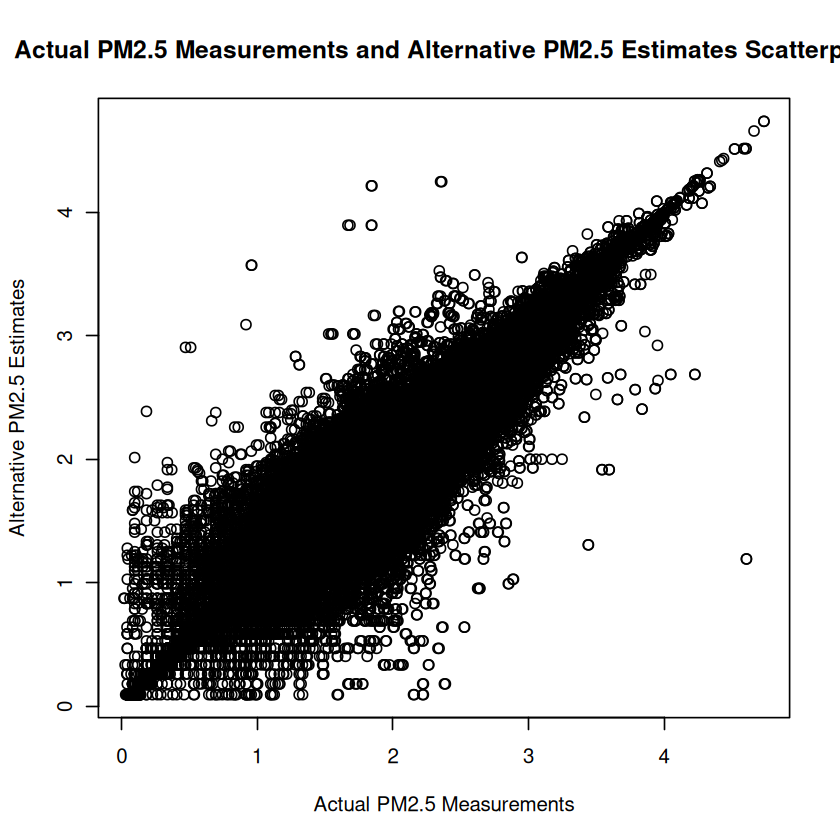

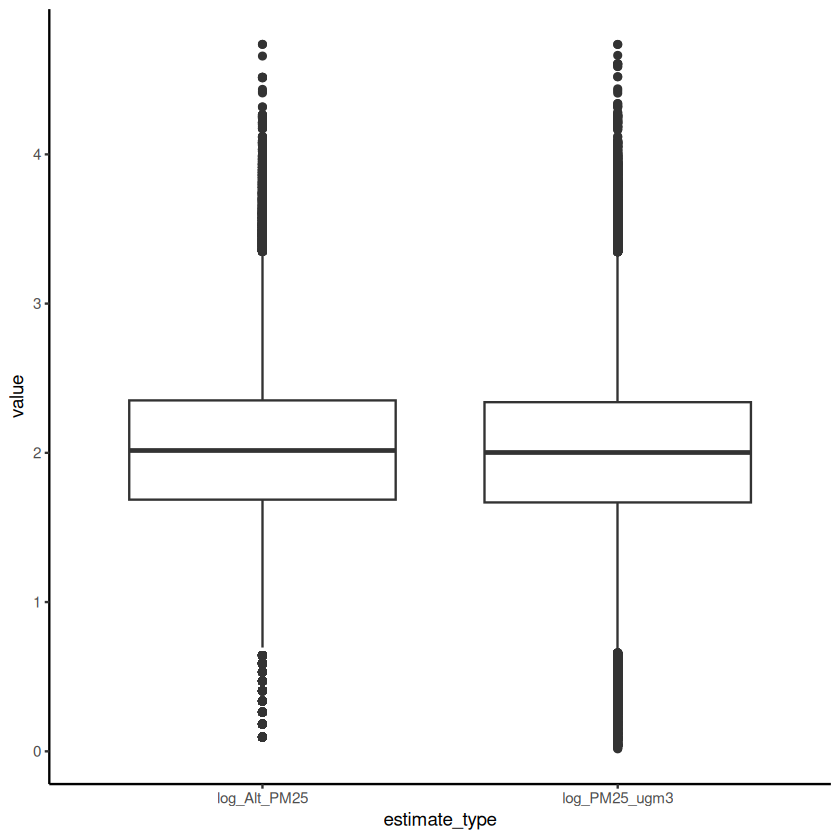

In [32]:
#Purpose of Cell: Assess variabels for possible correlation and identify any outliers
plot(
    x = DF_altpm25_processed01$log_PM25_ugm3, 
    y = DF_altpm25_processed01$log_Alt_PM25, 
    xlab = "Actual PM2.5 Measurements", 
    ylab = "Alternative PM2.5 Estimates", 
    main = "Actual PM2.5 Measurements and Alternative PM2.5 Estimates Scatterplot"
)

#Look for outliers
DF_altpm25_processed01 %>%
    pivot_longer(c(log_PM25_ugm3, log_Alt_PM25), names_to="estimate_type", values_to="value") %>%
    ggplot(aes(x=estimate_type, y=value)) +
    geom_boxplot() +
    theme_classic()

#Conclusion: There are still outliers in the dataset. This wll need to be explored in future research.

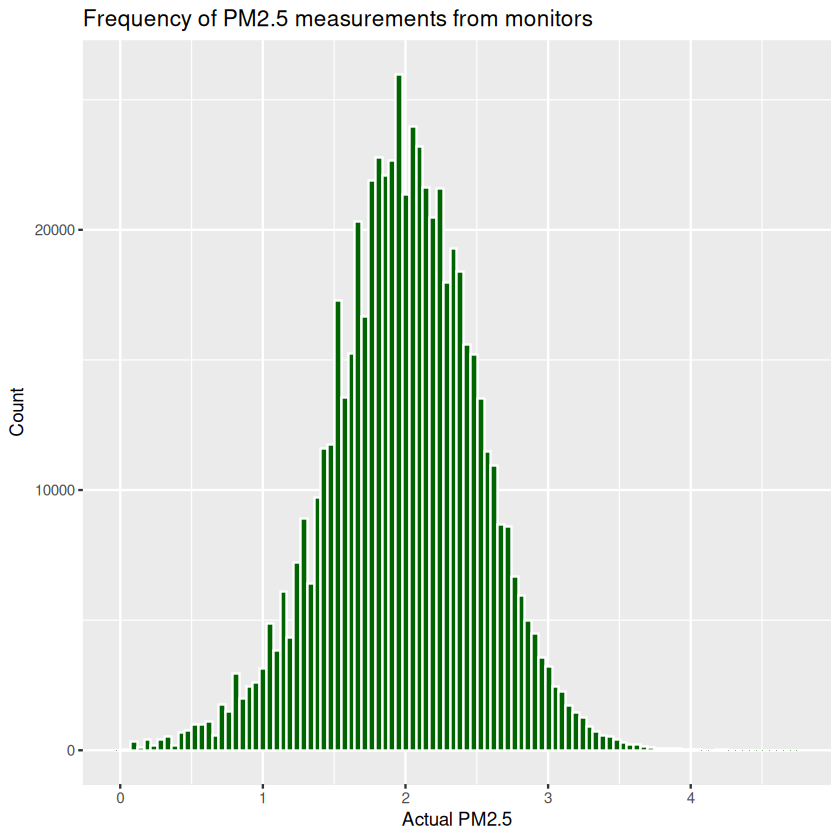

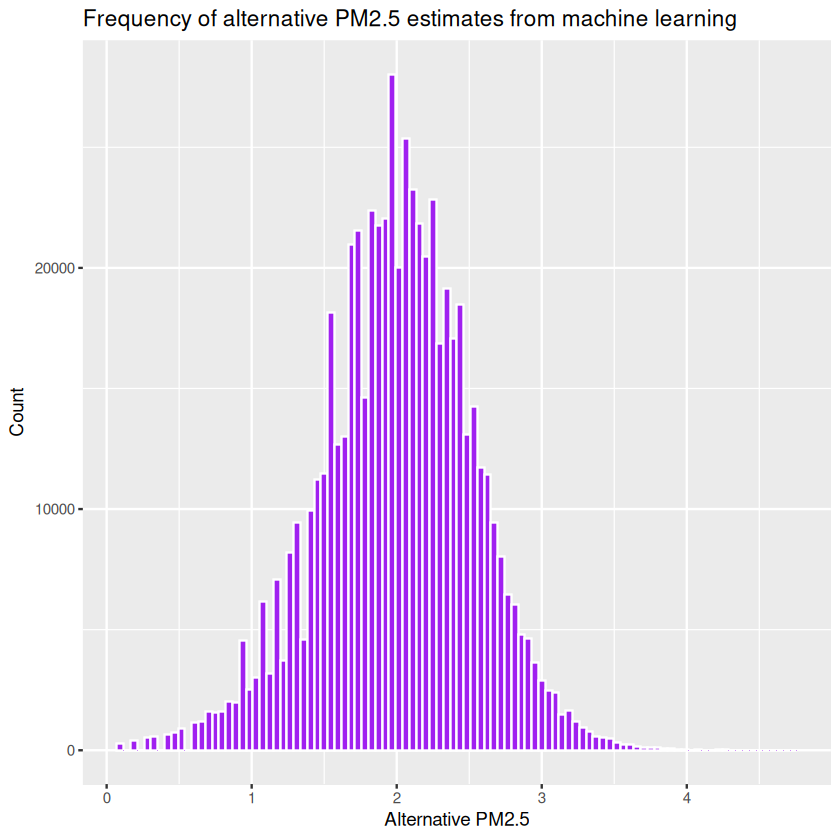

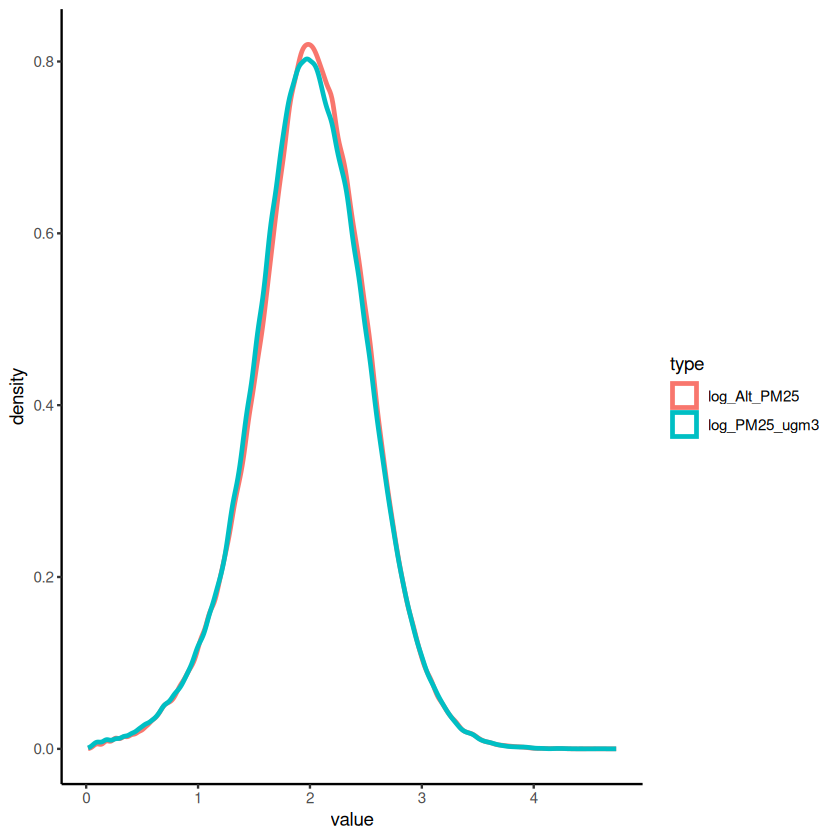

In [33]:
#Purpose of Cell: Check the shape of the data

#Histogram of Actual PM25 using ggplot2.
ggplot(DF_altpm25_processed01, aes(x = log_PM25_ugm3)) +
    geom_histogram(bins= 100, fill = "dark green", color = "white") +
    labs(title = "Frequency of PM2.5 measurements from monitors",
           x = "Actual PM2.5",
           y = "Count")

#Histogram of Alt PM25 using ggplot2.
ggplot(DF_altpm25_processed01, aes(x = log_Alt_PM25)) +
    geom_histogram(bins= 100, fill = "purple", color = "white") +
    labs(title = "Frequency of alternative PM2.5 estimates from machine learning",
           x = "Alternative PM2.5",
           y = "Count")

#Density Plot of Actual PM2.5 and Alt PM2.5
DF_altpm25_processed_long01 <- DF_altpm25_processed01 %>%
    pivot_longer(
        cols = c(log_PM25_ugm3,log_Alt_PM25),
        names_to = "type",
        values_to = "value",    
    )

ggplot(DF_altpm25_processed_long01, aes(x = value, color = type)) +
    geom_density(linewidth = 1) +
    theme_classic()

#Conclusion: The transformation appears to have normally distributed the data. Next step is to test using a QQ plot.

In [0]:
#Purpose of Cell: Check normality of data using QQ plot